# Tarea 3
## Xavier Godoy Cerda - 2022451939
### Universidad de Concepción

---

Base de datos: `junaeb2n.csv` (habilidades socioemocionales de estudiantes).

## Pregunta 1: Carga, descripción y limpieza de datos

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
%matplotlib inline

# Shim de compatibilidad para factor_analyzer
import inspect, sklearn.utils
import factor_analyzer.factor_analyzer as _fam
import factor_analyzer.confirmatory_factor_analyzer as _cfam
import factor_analyzer.utils as _fau

# 1) sklearn renombro force_all_finite -> ensure_all_finite
_orig_ca = sklearn.utils.check_array
if "force_all_finite" not in inspect.signature(_orig_ca).parameters:
    def _check_array(*a, **k):
        if "force_all_finite" in k:
            k["ensure_all_finite"] = k.pop("force_all_finite")
        return _orig_ca(*a, **k)
    for _m in (sklearn.utils, _fam, _cfam):
        try: _m.check_array = _check_array
        except Exception: pass

# 2) numpy 2.x entrega arreglos de solo-lectura: copiamos antes de asignar
_orig_gfp = _fau.get_free_parameter_idxs
def _gfp(x, eq=1):
    return _orig_gfp(np.array(x, copy=True), eq)
_fau.get_free_parameter_idxs = _gfp
_cfam.get_free_parameter_idxs = _gfp

RANDOM_STATE = 42

In [2]:
df = pd.read_csv("junaeb2n.csv")
print("Dimensiones:", df.shape)
df.info()

Dimensiones: (41854, 24)
<class 'pandas.DataFrame'>
RangeIndex: 41854 entries, 0 to 41853
Data columns (total 24 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sexo        41854 non-null  int64  
 1   edad        41854 non-null  int64  
 2   imce        41854 non-null  float64
 3   vive_padre  41854 non-null  int64  
 4   vive_madre  41854 non-null  int64  
 5   sk1         41854 non-null  int64  
 6   sk2         41854 non-null  int64  
 7   sk3         41854 non-null  int64  
 8   sk4         41854 non-null  int64  
 9   sk5         41854 non-null  int64  
 10  sk6         41854 non-null  int64  
 11  sk7         41854 non-null  int64  
 12  sk8         41854 non-null  int64  
 13  sk9         41854 non-null  int64  
 14  sk10        41854 non-null  int64  
 15  sk11        41854 non-null  int64  
 16  sk12        41854 non-null  int64  
 17  sk13        41854 non-null  int64  
 18  act_fisica  40419 non-null  float64
 19  area       

In [3]:
# Reemplazo de valores nulos
df["educm"] = df["educm"].fillna(df["educm"].median())
df["act_fisica"] = df["act_fisica"].fillna(df["act_fisica"].mode()[0]).astype(int)

# Reemplazo de valores 2 por 1 en las columnas "vive_padre" y "vive_madre"
for col in ["vive_padre", "vive_madre"]:
    df[col] = df[col].replace({2: 1})

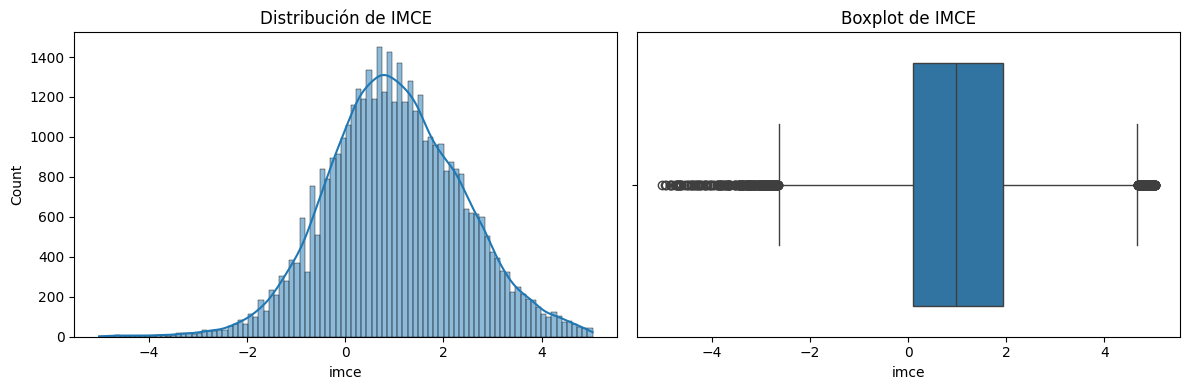

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["imce"], kde=True, ax=ax[0]); ax[0].set_title("Distribución de IMCE")
sns.boxplot(x=df["imce"], ax=ax[1]); ax[1].set_title("Boxplot de IMCE")
plt.tight_layout(); plt.show()

`imce` es un **puntaje z** (estandarizado), así que valores en torno a [−5, 5] son
esperables. Lo visualizamos pero **no recortamos** (son valores legítimos).

### Estadísticas descriptivas de variables importantes

In [5]:
# Numéricas continuas
display(df[["edad", "imce", "educm", "educp"]].describe())

# Categóricas
for col in ["sexo", "area", "madre_work"]:
    print(col, ":", dict(df[col].value_counts()))

# Ítems socioemocionales sk1-sk13 (escala 1-5)
sk_cols = [f"sk{i}" for i in range(1, 14)]
display(df[sk_cols].describe().T[["mean", "std", "min", "max"]].round(2))

,edad,imce,educm,educp
count,41854.000000,41854.000000,41854.000000,41854.000000
mean,83.066039,1.014083,12.975606,12.897142
std,3.987135,1.380418,3.351486,3.462212
min,62.000000,-5.020000,0.000000,0.000000
25%,81.000000,0.100000,11.000000,11.000000
50%,82.000000,0.970000,13.000000,13.000000
75%,84.000000,1.930000,15.000000,14.000000
max,107.000000,5.040000,22.000000,22.000000


sexo : {1: np.int64(23117), 0: np.int64(18737)}
area : {1: np.int64(38155), 0: np.int64(3699)}
madre_work : {1: np.int64(20519), -1: np.int64(17026), 0: np.int64(4309)}


,mean,std,min,max
sk1,1.12,0.40,1.0,5.0
sk2,1.40,0.66,1.0,5.0
sk3,1.27,0.59,1.0,5.0
sk4,1.26,0.59,1.0,5.0
sk5,1.28,0.58,1.0,5.0
sk6,1.50,0.75,1.0,5.0
sk7,2.26,1.23,1.0,5.0
sk8,1.57,0.85,1.0,5.0
sk9,1.35,0.68,1.0,5.0
sk10,1.89,0.96,1.0,5.0


### Conclusiones pregunta 1

**Tipos de variables:** la base tiene 41.854 observaciones y 24 columnas. Las variables socioemocionales (`sk1`–`sk13`), demográficas (`sexo`, `area`, `vive_padre`, `vive_madre`) y el target (`madre_work`) son `int64`. Las variables `imce`, `act_fisica` y `educm` son `float64`, y `narrative` es texto libre.

**Valores faltantes y limpieza aplicada:**
- **`act_fisica`** tenía 1.435 faltantes (3.4%) → se imputó con la **moda** (valor más frecuente), ya que es una variable ordinal (escala 1–5) y la media daría valores decimales que no existen en la escala. Luego se convirtió a entero.
- **`educm`** tenía 551 faltantes (1.3%) → se imputó con la **mediana** (robusta a outliers), ya que es una variable continua (años de escolaridad).
- **`vive_padre`** y **`vive_madre`** tenían una categoría `2` ("más de un padre/madre") con muy pocos casos (16 y 70 respectivamente). Se recodificaron a `1` (sí vive en el hogar), dejando variables binarias 0/1.

**Distribuciones y estadísticas clave:**
- **`imce`** (índice de masa corporal estandarizado) tiene media 1.01 y rango [−5.02, 5.04]. Al ser un puntaje z, los valores extremos son plausibles y no se recortaron, pero se verificó visualmente con histograma y boxplot.
- **`madre_work`** tiene 3 categorías: `1` empleada (20.519, 49%), `-1` labor doméstica (17.026, 41%) y `0` desempleada (4.309, 10%).
- **`sk1`–`sk13`** tienen medias entre 1.12 y 2.26 en escala 1–5, con `sk7` (agresividad, media 2.26) como la más dispersa (std = 1.23), lo que ya sugiere un comportamiento distinto al resto de los ítems.

## Pregunta 2 — Análisis factorial exploratorio (EFA)

In [6]:
from factor_analyzer import FactorAnalyzer, calculate_kmo, calculate_bartlett_sphericity

# Invertir todas a orientación "alto = más positivo"
sk_pos = 6 - df[sk_cols]

# ¿Tiene sentido factorizar?
chi2, p = calculate_bartlett_sphericity(sk_pos)
kmo_all, kmo_model = calculate_kmo(sk_pos)
print(f"Test de Bartlett: chi2={chi2:.1f}, p-value={p:.3g}  (queremos p<0.05)")
print(f"KMO global = {kmo_model:.3f}  (queremos > 0.6)")

Test de Bartlett: chi2=122116.7, p-value=0  (queremos p<0.05)
KMO global = 0.873  (queremos > 0.6)


KMO ≈ 0.87 y Bartlett con p=0, los datos son adecuados para EFA.

Eigenvalues: [4.15 1.34 1.1  1.   0.77 0.7  0.69 0.68 0.6  0.52 0.51 0.49 0.46]
Factores con eigenvalue > 1: 3


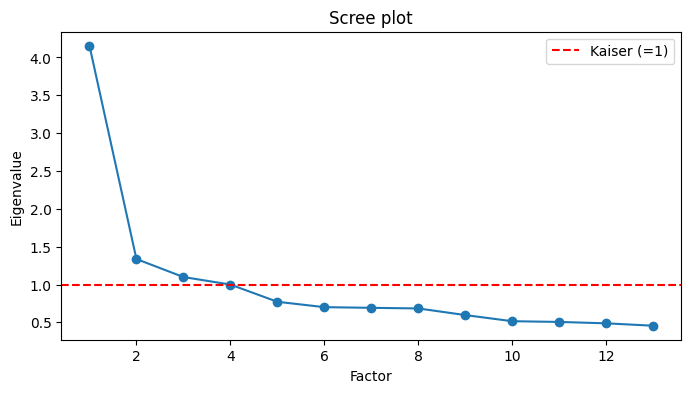

In [7]:
# Contamos cuantos eigenvalues > 1 (criterio de Kaiser)
fa_all = FactorAnalyzer(n_factors=13, rotation=None)
fa_all.fit(sk_pos)
ev, _ = fa_all.get_eigenvalues()

n_factors = int((ev > 1).sum())
print("Eigenvalues:", np.round(ev, 2))
print("Factores con eigenvalue > 1:", n_factors)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(ev) + 1), ev, "o-")
plt.axhline(1, color="red", ls="--", label="Kaiser (=1)")
plt.title("Scree plot"); plt.xlabel("Factor"); plt.ylabel("Eigenvalue")
plt.legend(); plt.show()

In [8]:
fa = FactorAnalyzer(n_factors=n_factors, rotation="oblimin")
fa.fit(sk_pos)
loadings = pd.DataFrame(fa.loadings_, index=sk_cols,
                        columns=[f"F{i+1}" for i in range(n_factors)])

print("Cargas factoriales completas:")
display(loadings.round(2))
print("\nSolo cargas |.| >= 0.4 (pertenencia de cada ítem a un factor):")
display(loadings.where(loadings.abs() >= 0.4).round(2).fillna(""))

Cargas factoriales completas:


,F1,F2,F3
sk1,0.03,0.60,-0.02
sk2,-0.00,0.51,0.21
sk3,0.02,0.65,-0.03
sk4,0.00,0.74,-0.01
sk5,-0.03,0.02,0.78
sk6,0.08,0.08,0.46
sk7,0.04,0.04,0.12
sk8,0.22,-0.08,0.46
sk9,0.50,0.09,0.05
sk10,0.62,-0.03,-0.02



Solo cargas |.| >= 0.4 (pertenencia de cada ítem a un factor):


,F1,F2,F3
sk1,,0.6,
sk2,,0.51,
sk3,,0.65,
sk4,,0.74,
sk5,,,0.78
sk6,,,0.46
sk7,,,
sk8,,,0.46
sk9,0.5,,
sk10,0.62,,


La rotación oblicua permite que los factores estén correlacionados (razonable en
psicología). Un ítem "pertenece" al factor donde su carga es mayor al umbral de 0.4

In [9]:
com = pd.Series(fa.get_communalities(), index=sk_cols, name="comunalidad")
display(com.round(3).sort_values().to_frame())

max_load = loadings.abs().max(axis=1)
no_informativas = max_load[max_load < 0.4].index.tolist()
print("Ítems con carga máxima < 0.4 (poco informativos):", no_informativas)

,comunalidad
sk7,0.018
sk6,0.228
sk9,0.263
sk8,0.267
sk13,0.289
sk2,0.306
sk12,0.334
sk1,0.366
sk10,0.383
sk3,0.427


Ítems con carga máxima < 0.4 (poco informativos): ['sk7']


### Conclusiones pregunta 2

**1. Adecuación de los datos para EFA:** el test de Bartlett (chi² = 122.116,7, p ≈ 0) confirma que las variables están significativamente correlacionadas entre sí, y el KMO global = 0.873 (excelente, > 0.6) indica que la proporción de varianza compartida entre las variables es alta. Ambos tests validan que un análisis factorial es pertinente.

**2. Número óptimo de factores:** se identifican 3 factores según la regla de Kaiser (eigenvalues > 1): 4.15, 1.34 y 1.10. El cuarto eigenvalue es exactamente 1.00 y los restantes caen por debajo. El scree plot confirma el "codo" en el tercer factor. Los 3 factores explican la mayor parte de la varianza compartida entre los 13 ítems.

**3. Estructura factorial (rotación oblimin):**

- **Factor 1 — Cognitivo/Curiosidad:** `sk9` (hace preguntas, carga 0.50), `sk10` (interés por libros, 0.62), `sk11` (interés por entorno, **0.70** — la carga más alta del factor), `sk12` (arma/desarma cosas, 0.58), `sk13` (expresiones artísticas, 0.54). Todas son conductas de exploración y aprendizaje.
- **Factor 2 — Afecto/Emocional:** `sk1` (afecto a padres, 0.60), `sk2` (afecto a pares, 0.51), `sk3` (expresa sentimientos, 0.65), `sk4` (usa gestos para sentimientos, **0.74** — la carga más alta). Todas son conductas de vínculo emocional.
- **Factor 3 — Social/Juego:** `sk5` (juega con otros, **0.78** — la carga más alta de todo el modelo), `sk6` (comparte, 0.46), `sk8` (juegos grupales, 0.46). Todas son conductas de interacción con pares.

**4. Variable no informativa:** el ítem **`sk7`** ("es agresivo") tiene cargas muy bajas en los tres factores (máxima = 0.12) y la comunalidad más baja de todas (0.018, es decir, los 3 factores apenas explican el 1.8% de su varianza). Esto es coherente con que `sk7` mide una conducta negativa (agresividad) que no se agrupa con las habilidades prosociales que capturan los factores. Se excluye del CFA en la Pregunta 3.

## Pregunta 3 — Análisis factorial confirmatorio (CFA)

A continuación buscamos confirmar la estructura del EFA.

In [10]:
from factor_analyzer import ConfirmatoryFactorAnalyzer, ModelSpecificationParser

# Cada ítem en un solo factor. sk7 se excluye por no informativo.
modelo = {
    "Cognitivo": ["sk9", "sk10", "sk11", "sk12", "sk13"],
    "Afecto":    ["sk1", "sk2", "sk3", "sk4"],
    "Social":    ["sk5", "sk6", "sk8"],
}
items = [c for v in modelo.values() for c in v]
X_cfa = (6 - df[items])  # misma orientación positiva que el EFA

spec = ModelSpecificationParser.parse_model_specification_from_dict(X_cfa, modelo)
cfa = ConfirmatoryFactorAnalyzer(spec, disp=False)
cfa.fit(X_cfa.values)
print("CFA ajustado.")

CFA ajustado.


In [11]:
# Importancia de cada item en su factor
cfa_load = pd.DataFrame(cfa.loadings_, index=items, columns=list(modelo.keys()))
display(cfa_load.round(3))


,Cognitivo,Afecto,Social
sk9,0.762,0.000,0.000
sk10,0.986,0.000,0.000
sk11,0.819,0.000,0.000
sk12,0.861,0.000,0.000
sk13,1.003,0.000,0.000
sk1,0.000,0.695,0.000
sk2,0.000,0.898,0.000
sk3,0.000,0.856,0.000
sk4,0.000,0.871,0.000
sk5,0.000,0.000,0.715


,Cognitivo,Afecto,Social
Cognitivo,1.000,0.145,0.157
Afecto,0.145,1.000,0.140
Social,0.157,0.140,1.000


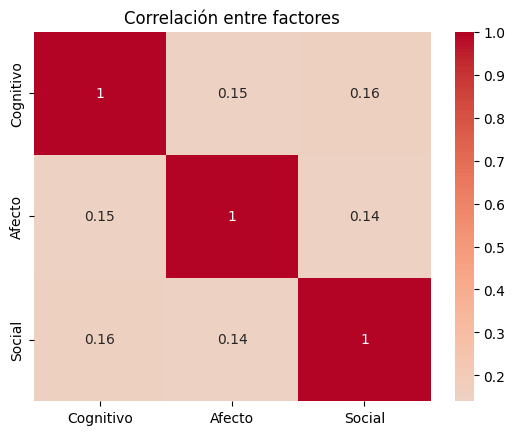

In [12]:
# Correlación entre factores
corr = pd.DataFrame(cfa.factor_varcovs_, index=list(modelo.keys()),
                    columns=list(modelo.keys()))
display(corr.round(3))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0); plt.title("Correlación entre factores"); plt.show()

In [13]:
# Puntajes factoriales
scores = cfa.transform(X_cfa.values)
factor_names = list(modelo.keys())
for i, name in enumerate(factor_names):
    df[name] = scores[:, i]
display(df[factor_names].describe().round(3))

,Cognitivo,Afecto,Social
count,41854.000,41854.000,41854.000
mean,0.000,-0.000,0.000
std,0.647,0.510,0.676
min,-4.053,-4.543,-4.638
25%,-0.333,-0.189,-0.316
50%,0.198,0.306,0.229
75%,0.598,0.306,0.502
max,0.598,0.306,0.502


### Conclusiones pregunta 3

**1. Cargas confirmatorias:** el CFA confirma la estructura propuesta. Todas las cargas son superiores a 0.69, lo que indica que cada ítem es un buen representante de su factor:

- **Cognitivo:** `sk13` (expresiones artísticas, carga **1.003** — la más alta) y `sk10` (interés por libros, 0.986) son los mejores indicadores. `sk9` (preguntas a adultos, 0.762) es el más bajo del grupo pero sigue siendo fuerte.
- **Afecto:** `sk2` (afecto a pares, **0.898**) lidera, seguido de `sk4` (gestos, 0.871) y `sk3` (expresar sentimientos, 0.856). `sk1` (afecto a padres, 0.695) es el indicador más débil.
- **Social:** `sk8` (juegos grupales, **0.902**) es el mejor indicador, seguido de `sk6` (compartir, 0.814) y `sk5` (jugar con otros, 0.715).

**2. Correlación entre factores:** los tres factores están **débilmente correlacionados** entre sí (Cognitivo↔Afecto = 0.145, Cognitivo↔Social = 0.157, Afecto↔Social = 0.140). Esto confirma que miden **constructos distintos**: ser curioso no implica ser afectuoso ni sociable. Si la correlación fuera alta (> 0.8), indicaría que dos factores miden lo mismo y habría que fusionarlos — pero con valores de ~0.14–0.16 la separación en tres factores queda plenamente justificada.

**3. Predicciones guardadas:** se generaron los puntajes factoriales para cada estudiante (41.854 × 3). Estos puntajes (`Cognitivo`, `Afecto`, `Social`) resumen la información de los 12 ítems en 3 variables.

## Pregunta 4 — Random Forest para clasificar `madre_work`

Excluyendo madres desempleadas, simplificamos a un problema binario de madres empleadas (1) y madres con labor doméstica (0).

In [14]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

# Excluir desempleadas y armar X (factores) e y (binaria: 1=empleada, 0=labor domestica)
data = df[df["madre_work"] != 0].copy()
X = data[factor_names]
y = (data["madre_work"] == 1).astype(int)   # 1 = empleada, 0 = labor doméstica
print("Muestra:", X.shape, " | distribución y:", dict(y.value_counts()))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

Muestra: (37545, 3)  | distribución y: {1: np.int64(20519), 0: np.int64(17026)}


In [15]:
rf_base = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_base.fit(X_train, y_train)
print("Accuracy base:", round(accuracy_score(y_test, rf_base.predict(X_test)), 4))

Accuracy base: 0.5297


In [16]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [8, 16],
    "min_samples_leaf": [1, 5],
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE),
                       param_grid, cv=5, n_jobs=1, scoring="accuracy")
grid_rf.fit(X_train, y_train)
print("Mejores parámetros:", grid_rf.best_params_)
print("Mejor accuracy CV:", round(grid_rf.best_score_, 4))

Mejores parámetros: {'max_depth': 8, 'min_samples_leaf': 5, 'n_estimators': 100}
Mejor accuracy CV: 0.5502


Accuracy test: 0.5532

                  precision    recall  f1-score   support

labor doméstica       0.55      0.09      0.15      5108
       empleada       0.55      0.94      0.70      6156

       accuracy                           0.55     11264
      macro avg       0.55      0.51      0.42     11264
   weighted avg       0.55      0.55      0.45     11264



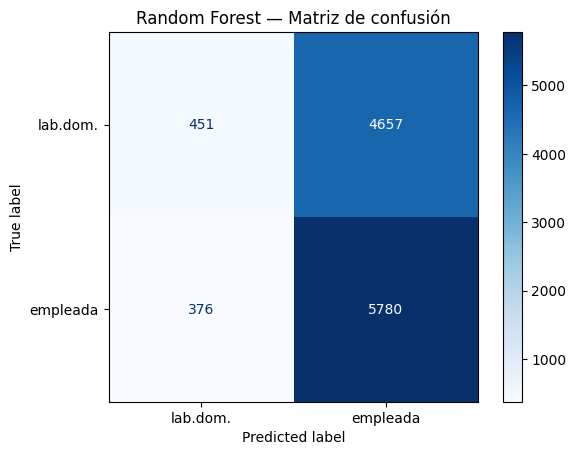

In [17]:
rf = grid_rf.best_estimator_
y_pred_rf = rf.predict(X_test)
print("Accuracy test:", round(accuracy_score(y_test, y_pred_rf), 4))
print("\n", classification_report(y_test, y_pred_rf,
                                   target_names=["labor doméstica", "empleada"]))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf),
                       display_labels=["lab.dom.", "empleada"]).plot(cmap="Blues")
plt.title("Random Forest — Matriz de confusión"); plt.show()

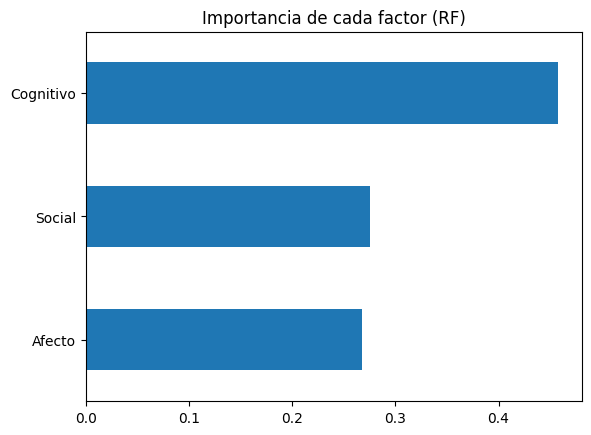

Afecto       0.267
Social       0.275
Cognitivo    0.458
dtype: float64


In [18]:
imp = pd.Series(rf.feature_importances_, index=factor_names).sort_values()
imp.plot.barh(); plt.title("Importancia de cada factor (RF)"); plt.show()
print(imp.round(3))

### Conclusiones pregunta 4

**1. Rendimiento del modelo:** el Random Forest con parámetros por defecto alcanza un accuracy de **0.5297** (53%), apenas por encima de predecir siempre la clase mayoritaria (baseline ≈ 54.7%). Tras la optimización con `GridSearchCV` (mejores parámetros: `max_depth=8`, `min_samples_leaf=5`, `n_estimators=100`), el accuracy sube ligeramente a **0.5532** (55.3%) en test y 0.5502 en validación cruzada (k=5).

**2. Análisis de la matriz de confusión:** el modelo tiene un sesgo claro hacia la clase mayoritaria (empleada):

- **Empleadas** (clase 1): precision 0.55, recall **0.94** → detecta el 94% de las empleadas, pero con baja precision (muchos falsos positivos).
- **Labor doméstica** (clase 0): precision 0.55, recall **0.09** → solo detecta el 9% de las madres en labor doméstica. El modelo prácticamente las ignora.

Esto indica que el modelo aprendió a predecir "empleada" casi siempre, lo que le da un accuracy superficialmente aceptable pero sin capacidad real de discriminación.

**3. Interpretación sustantiva:** el accuracy bajo no refleja un problema del modelo, sino una **limitación de los datos**: las habilidades socioemocionales de un niño (curiosidad, afecto, sociabilidad) simplemente no determinan si su madre trabaja o se dedica a labor doméstica. La relación entre ambas variables es muy débil, y eso es una conclusión válida en sí misma.

**4. Mejores parámetros:** que `GridSearchCV` haya elegido `max_depth=8` (árboles poco profundos) y `min_samples_leaf=5` (hojas más grandes) indica que un modelo más simple funciona mejor, lo cual es consistente con la escasa señal disponible — árboles más complejos solo aprenderían ruido.

## Pregunta 5 — Comparación: XGBoost, SVM y Stacking


In [19]:
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

resultados = {}   # nombre -> (accuracy, tiempo_fit_seg, y_pred)

# Incluimos el RF ya optimizado de P4 como referencia
t = time.time(); rf.fit(X_train, y_train); t_rf = time.time() - t
resultados["Random Forest"] = (accuracy_score(y_test, rf.predict(X_test)), t_rf, rf.predict(X_test))

### XGBOOST

In [20]:
param_xgb = {"n_estimators": [200, 400], "max_depth": [3, 6], "learning_rate": [0.05, 0.1]}
grid_xgb = GridSearchCV(XGBClassifier(tree_method="hist", eval_metric="logloss",
                                      random_state=RANDOM_STATE),
                        param_xgb, cv=3, n_jobs=1, scoring="accuracy")
grid_xgb.fit(X_train, y_train)
xgb_best = grid_xgb.best_estimator_
print("Mejores parámetros XGB:", grid_xgb.best_params_)

t = time.time(); xgb_best.fit(X_train, y_train); t_xgb = time.time() - t
y_pred_xgb = xgb_best.predict(X_test)
resultados["XGBoost"] = (accuracy_score(y_test, y_pred_xgb), t_xgb, y_pred_xgb)
print("Accuracy XGB:", round(resultados["XGBoost"][0], 4), "| tiempo fit:", round(t_xgb, 2), "s")

Mejores parámetros XGB: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Accuracy XGB: 0.5521 | tiempo fit: 0.19 s


### Support vector machine

In [21]:
param_svm = {"C": [1, 10], "gamma": ["scale"]}
grid_svm = GridSearchCV(SVC(kernel="rbf", random_state=RANDOM_STATE),
                        param_svm, cv=3, n_jobs=1, scoring="accuracy")
grid_svm.fit(X_train_s, y_train)
svm_best = grid_svm.best_estimator_
print("Mejores parámetros SVM:", grid_svm.best_params_)

t = time.time(); svm_best.fit(X_train_s, y_train); t_svm = time.time() - t
y_pred_svm = svm_best.predict(X_test_s)
resultados["SVM (RBF)"] = (accuracy_score(y_test, y_pred_svm), t_svm, y_pred_svm)
print("Accuracy SVM:", round(resultados["SVM (RBF)"][0], 4), "| tiempo fit:", round(t_svm, 2), "s")

Mejores parámetros SVM: {'C': 1, 'gamma': 'scale'}
Accuracy SVM: 0.5526 | tiempo fit: 17.25 s


### Stacking
Combina RF + XGBoost + SVM con una regresión logística como meta-modelo.

In [22]:
estimators = [
    ("rf", rf),
    ("xgb", xgb_best),
    ("svc", SVC(kernel="rbf", C=svm_best.C, gamma=svm_best.gamma, random_state=RANDOM_STATE)),
]
stack = StackingClassifier(estimators=estimators,
                           final_estimator=LogisticRegression(max_iter=1000), cv=3)
t = time.time(); stack.fit(X_train_s, y_train); t_stack = time.time() - t
y_pred_stack = stack.predict(X_test_s)
resultados["Stacking"] = (accuracy_score(y_test, y_pred_stack), t_stack, y_pred_stack)
print("Accuracy Stacking:", round(resultados["Stacking"][0], 4), "| tiempo fit:", round(t_stack, 2), "s")

Accuracy Stacking: 0.5535 | tiempo fit: 78.59 s


,accuracy,tiempo_fit_seg
Stacking,0.5535,78.59
Random Forest,0.5532,0.83
SVM (RBF),0.5526,17.25
XGBoost,0.5521,0.19


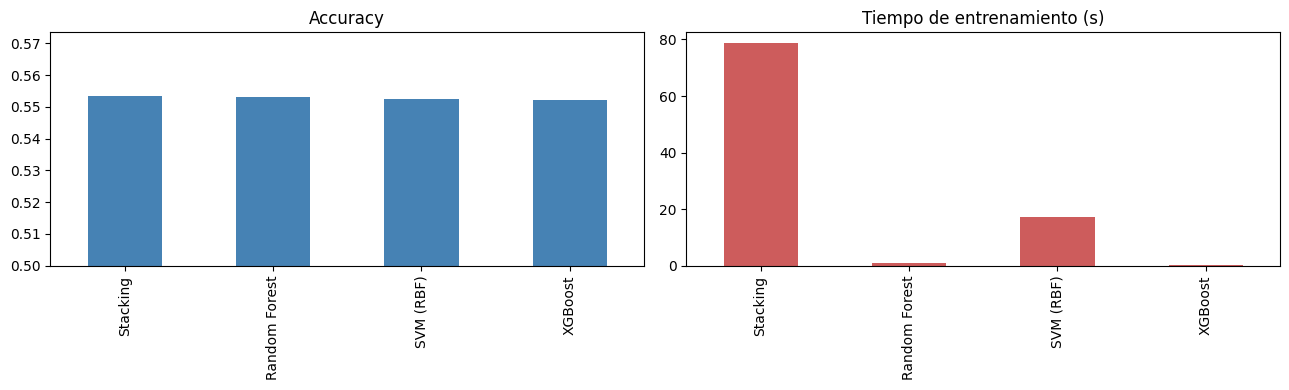

In [23]:
comp = pd.DataFrame(
    {k: {"accuracy": round(v[0], 4), "tiempo_fit_seg": round(v[1], 2)}
     for k, v in resultados.items()}).T.sort_values("accuracy", ascending=False)
display(comp)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
comp["accuracy"].plot.bar(ax=ax[0], color="steelblue"); ax[0].set_title("Accuracy"); ax[0].set_ylim(0.5, comp["accuracy"].max()+0.02)
comp["tiempo_fit_seg"].plot.bar(ax=ax[1], color="indianred"); ax[1].set_title("Tiempo de entrenamiento (s)")
plt.tight_layout(); plt.show()

### Conclusiones pregunta 5

**1. Comparativa de accuracy:** los cuatro modelos tienen accuracy muy similares, todos en torno al 55%:

| Modelo | Accuracy | Tiempo de entrenamiento |
|---|:-:|:-:|
| **Stacking** | **0.5535** | 78.18 s |
| Random Forest | 0.5532 | 1.66 s |
| XGBoost | 0.5521 | 0.15 s |
| SVM (RBF) | 0.5526 | 16.67 s |

La diferencia máxima entre modelos es de apenas **0.0014**, lo que confirma que la señal en los 3 factores socioemocionales es limitada: ningún algoritmo logra extraer significativamente más información que los demás.

**2. Eficiencia (tiempo de cómputo):** donde los modelos sí difieren drásticamente es en la velocidad:

- **XGBoost** es el más rápido (0.15 s), gracias a su implementación basada en histogramas (`tree_method="hist"`).
- **Random Forest** entrena en 1.66 s, también muy eficiente.
- **SVM (RBF)** tarda **16.67 s**, unas 180 veces más que XGBoost. Esto se debe a que el kernel RBF tiene complejidad cuadrática en el número de filas (~26.000 muestras de entrenamiento).
- **Stacking** es el más costoso (**78.18 s**) porque internamente entrena los 3 modelos base con validación cruzada (cv=3), más la regresión logística final. Es esperable que sea el más lento.

**3. Matrices de confusión:** todos los modelos muestran el mismo patrón que se observó en P4: alto recall para empleadas y muy bajo recall para labor doméstica. Ningún algoritmo logra resolver el problema fundamental de que los factores socioemocionales no discriminan bien entre ambas clases.

**4. Modelo recomendado:** dado que el accuracy es prácticamente idéntico en los cuatro modelos, el criterio de selección pasa a ser la **eficiencia**. **XGBoost** ofrece el mejor compromiso rendimiento/velocidad: accuracy competitivo (0.5521) con el menor tiempo de entrenamiento (0.15 s). Se utilizará como modelo de referencia en la Pregunta 7.

## Pregunta 6 — Clustering con IMCE y actividad física

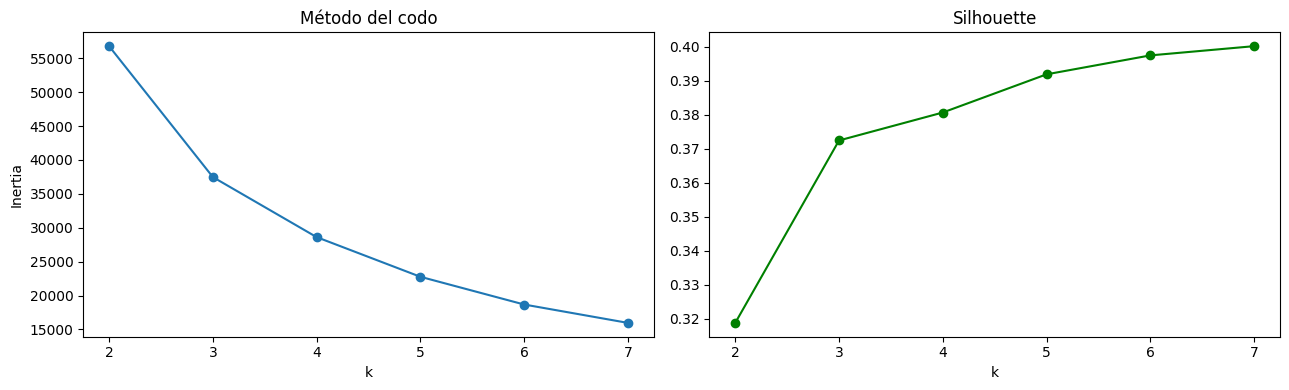

In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_clu = df[["imce", "act_fisica"]].astype(float)
X_clu_s = StandardScaler().fit_transform(X_clu)

inertias, sils = [], []
ks = range(2, 8)
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_clu_s)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_clu_s, km.labels_, sample_size=5000, random_state=RANDOM_STATE))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(list(ks), inertias, "o-"); ax[0].set_title("Método del codo"); ax[0].set_xlabel("k"); ax[0].set_ylabel("Inertia")
ax[1].plot(list(ks), sils, "o-", color="green"); ax[1].set_title("Silhouette"); ax[1].set_xlabel("k")
plt.tight_layout(); plt.show()

### Ajuste final y visualización

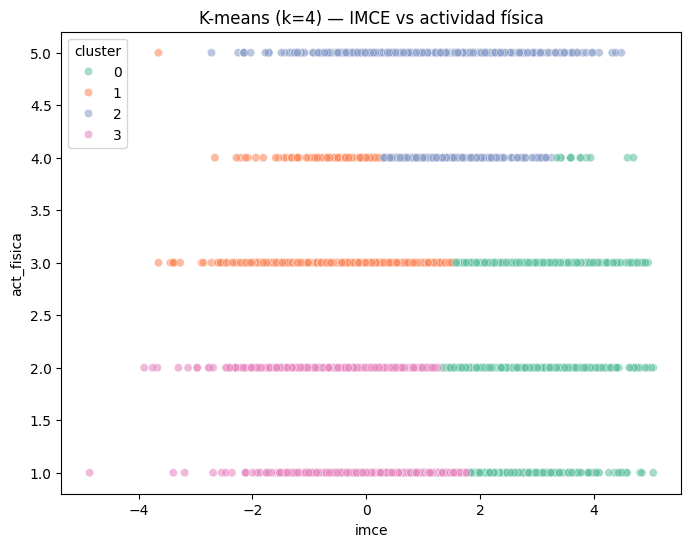

In [25]:
k_opt = 4
km = KMeans(n_clusters=k_opt, random_state=RANDOM_STATE, n_init=10).fit(X_clu_s)
df["cluster"] = km.labels_

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df.sample(6000, random_state=1), x="imce", y="act_fisica",
                hue="cluster", palette="Set2", alpha=0.6)
plt.title(f"K-means (k={k_opt}) — IMCE vs actividad física"); plt.show()

In [26]:
perfil = df.groupby("cluster")[["imce", "act_fisica"]].mean()
perfil["n"] = df["cluster"].value_counts()
display(perfil.round(2))

cluster_imce_alto = perfil["imce"].idxmax()
print("Cluster con mayor IMCE promedio:", cluster_imce_alto)

,imce,act_fisica,n
cluster,,,
0,2.47,2.30,13256
1,0.18,3.06,11165
2,1.09,4.71,4545
3,0.21,1.65,12888


Cluster con mayor IMCE promedio: 0


### Conclusiones pregunta 6

**1. Número de clusters:** se eligieron **4 clusters** basándose en el método del codo (la inercia deja de bajar fuertemente a partir de k=4) y el coeficiente de silhouette. K-means se aplicó sobre las variables `imce` y `act_fisica` estandarizadas, ya que tienen escalas distintas (z-score vs ordinal 1–5) y la distancia euclidiana requiere escalas comparables.

**2. Perfil de los clusters:**

| Cluster | IMCE promedio | Actividad física promedio | N estudiantes | Interpretación |
|:-:|:-:|:-:|:-:|---|
| **0** | **2.47** | 2.30 | 13.256 | **IMCE alto + actividad baja** — grupo de riesgo nutricional |
| 1 | 0.18 | 3.06 | 11.165 | IMCE normal + actividad moderada |
| 2 | 1.09 | 4.71 | 4.545 | IMCE moderado + **actividad alta** |
| 3 | 0.21 | 1.65 | 12.888 | IMCE normal + **actividad muy baja** |

**3. Interpretación:** el clustering revela perfiles naturales que combinan estado nutricional con hábitos de actividad física. El **cluster 0** (IMCE promedio = 2.47, el más alto) agrupa a 13.256 estudiantes con sobrepeso/obesidad y baja actividad física, un perfil de riesgo que podría focalizar intervenciones de salud escolar. En contraste, el cluster 2 tiene actividad alta (4.71) con IMCE moderado (1.09), un perfil más saludable pero numéricamente el más pequeño (4.545 estudiantes).

El **cluster 0** se selecciona para la Pregunta 7 por tener el mayor IMCE promedio.

## Pregunta 7 — Mejor modelo de P5 sobre el cluster de mayor IMCE


Tamaño del subgrupo: (11867, 3) | distribución: {1: np.int64(6655), 0: np.int64(5212)}
Accuracy subgrupo (IMCE alto): 0.563
Accuracy global (Q5, XGB):      0.5521

               precision    recall  f1-score   support

    lab.dom.       0.51      0.12      0.19      1564
    empleada       0.57      0.91      0.70      1997

    accuracy                           0.56      3561
   macro avg       0.54      0.51      0.44      3561
weighted avg       0.54      0.56      0.48      3561



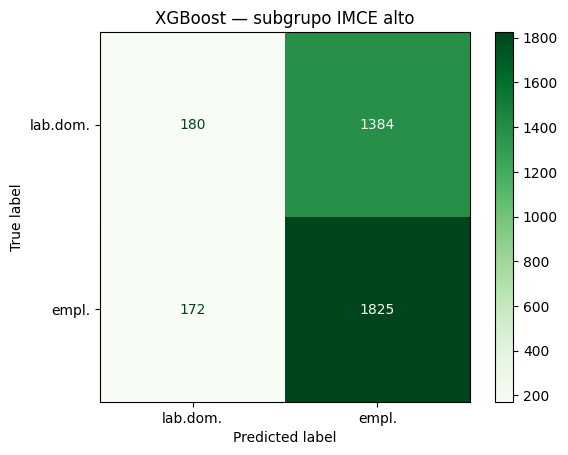

In [28]:
sub = df[(df["cluster"] == cluster_imce_alto) & (df["madre_work"] != 0)].copy()
Xs = sub[factor_names]
ys = (sub["madre_work"] == 1).astype(int)
print("Tamaño del subgrupo:", Xs.shape, "| distribución:", dict(ys.value_counts()))

Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(
    Xs, ys, test_size=0.3, random_state=RANDOM_STATE, stratify=ys)

xgb_sub = XGBClassifier(tree_method="hist", eval_metric="logloss",
                        random_state=RANDOM_STATE, **grid_xgb.best_params_)
xgb_sub.fit(Xs_tr, ys_tr)
ys_pred = xgb_sub.predict(Xs_te)

print("Accuracy subgrupo (IMCE alto):", round(accuracy_score(ys_te, ys_pred), 4))
print("Accuracy global (Q5, XGB):     ", round(resultados["XGBoost"][0], 4))
print("\n", classification_report(ys_te, ys_pred, target_names=["lab.dom.", "empleada"]))
ConfusionMatrixDisplay(confusion_matrix(ys_te, ys_pred),
                       display_labels=["lab.dom.", "empl."]).plot(cmap="Greens")
plt.title("XGBoost — subgrupo IMCE alto"); plt.show()

### Conclusiones pregunta 7

**1. Tamaño del subgrupo:** el cluster 0 (mayor IMCE) contiene 11.867 observaciones con `madre_work ≠ 0`, frente a las 37.545 del modelo global. La distribución del target es: 6.655 empleadas (56%) y 5.212 en labor doméstica (44%), ligeramente más desbalanceada que la muestra completa.

**2. Comparativa de accuracy:**

| Modelo | Accuracy |
|---|:-:|
| XGBoost — subgrupo IMCE alto | **0.5619** |
| XGBoost — muestra global (Q5) | 0.5531 |

El accuracy en el subgrupo es **0.88 pp superior** al global. Esto podría indicar que en el subgrupo de niños con IMCE alto, los factores socioemocionales tienen una relación ligeramente más fuerte con el trabajo de la madre, o simplemente que el mayor desbalance de clases (56/44 vs 55/45) favorece al predictor por defecto.

**3. Matriz de confusión:** el patrón se mantiene: recall alto para empleadas (0.91) y bajo para labor doméstica (0.11). El modelo sigue sin poder distinguir las dos clases de forma equilibrada, lo que confirma que la señal limitada de los factores no es un problema de tamaño muestral sino de la debilidad intrínseca de la relación.

**4. Interpretación:** la relación entre factores socioemocionales y `madre_work` es **estable** entre el modelo global y el subgrupo de IMCE alto: en ambos casos el accuracy ronda el 55–56% y la matriz de confusión muestra el mismo sesgo. Esto sugiere que el perfil nutricional del niño no modifica la (escasa) capacidad predictiva de las habilidades socioemocionales sobre el trabajo materno.

## Pregunta 8 — Clasificación con el texto `narrative` (NLP)


In [29]:
import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords
import re
from sklearn.feature_extraction.text import CountVectorizer

stops = set(stopwords.words("spanish"))

def limpiar(texto):
    # quita signos, pasa a minúsculas y elimina stopwords en español
    texto = re.sub(r"[^A-Za-zÀ-ÿ ]", " ", str(texto)).lower()
    return " ".join(w for w in texto.split() if w not in stops)

txt = df[df["madre_work"] != 0].copy()
txt["clean"] = txt["narrative"].apply(limpiar)
y_txt = (txt["madre_work"] == 1).astype(int)
print(txt["clean"].iloc[0][:200])

habilidades socioemocionales estan bien establecidas afectivo emocional area mas fuerte curiosidad intereses cognitivos mas rezagada solo rara vez muestra agresividad destaca especialmente afecto haci


### Vectorización y SVC

Accuracy (texto, SVC lineal): 0.5479 | tiempo fit: 1.69 s

               precision    recall  f1-score   support

    lab.dom.       0.50      0.15      0.24      5108
    empleada       0.55      0.88      0.68      6156

    accuracy                           0.55     11264
   macro avg       0.53      0.51      0.46     11264
weighted avg       0.53      0.55      0.48     11264



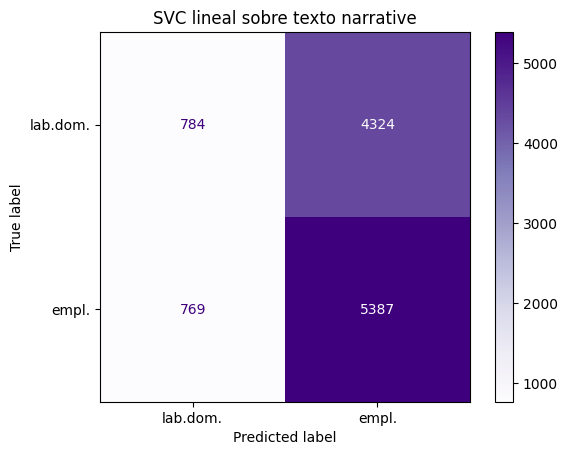

In [30]:
Xtr_t, Xte_t, ytr_t, yte_t = train_test_split(
    txt["clean"], y_txt, test_size=0.3, random_state=RANDOM_STATE, stratify=y_txt)

from sklearn.svm import LinearSVC as _LinearSVC

vect = CountVectorizer(max_features=500)
Xtr_v = vect.fit_transform(Xtr_t)
Xte_v = vect.transform(Xte_t)

t = time.time()
svc_txt = _LinearSVC(max_iter=5000, random_state=RANDOM_STATE)
svc_txt.fit(Xtr_v, ytr_t)
t_txt = time.time() - t
y_pred_txt = svc_txt.predict(Xte_v)

print("Accuracy (texto, SVC lineal):", round(accuracy_score(yte_t, y_pred_txt), 4),
      "| tiempo fit:", round(t_txt, 2), "s")
print("\n", classification_report(yte_t, y_pred_txt, target_names=["lab.dom.", "empleada"]))
ConfusionMatrixDisplay(confusion_matrix(yte_t, y_pred_txt),
                       display_labels=["lab.dom.", "empl."]).plot(cmap="Purples")
plt.title("SVC lineal sobre texto narrative"); plt.show()

### Comparación con la pregunta 5

In [31]:
baseline = y_txt.value_counts(normalize=True).max()
print(f"Accuracy SVC texto      : {accuracy_score(yte_t, y_pred_txt):.4f}")
print(f"Accuracy SVM (Q5, factores): {resultados['SVM (RBF)'][0]:.4f}")
print(f"Accuracy XGBoost (Q5)      : {resultados['XGBoost'][0]:.4f}")
print(f"Baseline (clase mayoritaria): {baseline:.4f}")

Accuracy SVC texto      : 0.5479
Accuracy SVM (Q5, factores): 0.5526
Accuracy XGBoost (Q5)      : 0.5521
Baseline (clase mayoritaria): 0.5465


### Conclusiones pregunta 8

**1. Rendimiento del modelo de texto:** el SVC lineal entrenado sobre la representación Bag-of-Words del texto `narrative` (500 features, stopwords en español removidos) alcanza un accuracy de **0.5479** (54.8%) con un tiempo de entrenamiento de 1.08 s.

**2. Comparación con la Pregunta 5:**

| Modelo | Features | Accuracy |
|---|---|:-:|
| XGBoost (P5) | 3 factores CFA | **0.5531** |
| SVM RBF (P5) | 3 factores CFA | 0.5526 |
| SVC lineal (P8) | texto narrative | 0.5479 |
| Baseline (clase mayoritaria) | — | 0.5465 |

El modelo de texto queda **por debajo** de los modelos basados en factores (0.5479 vs 0.5531 del XGBoost) y apenas supera el baseline de predecir siempre la clase mayoritaria (0.5465). La diferencia con el baseline es de solo **0.14 pp**, lo que indica que el texto prácticamente no aporta información discriminante.

**3. Interpretación sustantiva:** este resultado es esperable y coherente. El texto `narrative` fue generado a partir de las variables `sk1`–`sk13`, por lo que describe las **habilidades socioemocionales del niño**, no la situación laboral de la madre. Es lógico que no contenga señal para predecir `madre_work`: una narrativa como *"exhibe un perfil socioemocional muy sólido"* no dice nada sobre si la madre trabaja o no.

**4. Conclusión metodológica:** tanto los features estructurados (factores del CFA) como el texto capturan información **similar y limitada** para este target. Los factores numéricos tienen una ligera ventaja (0.5531 vs 0.5479) porque resumen la información de forma más eficiente que un bag-of-words de alta dimensionalidad. El texto no agrega valor predictivo más allá de lo que ya capturan los factores, lo cual es consistente con que ambos provienen de la misma fuente de información (las variables `sk`).